

Olá estudante!

Me chamo Rafael Meirelles e irei revisar o seu projeto hoje e em eventuais futuras submissões até que ele cumpra todos os requisitos para o aceite.
Conte comigo nessa jornada e não se preocupe se precisar ajustar alguns detalhes, é parte do processo e fundamental para que você exercite os conceitos que vem aprendendo e assim melhore a qualidade dos seus códigos e análises.

**Peço que mantenha e não altereos comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:


<div class="alert alert-danger">
<strong>Vermelho</strong>

Erro que precisa ser consertado, caso contrário, seu projeto não pode ser aceito

</div>

<div class="alert alert-warning">
<strong>Amarelo</strong>

Alerta de um erro não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise

</div>

<div class="alert alert-success">
<strong>Verde</strong>

Elogios
</div>

<div class="alert alert-info">
<strong>Comentário do estudante</strong>

Use uma caixa azul como essa para eventuais comentários que você gostaria de fazer para mim.
</div>




<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Trabalho muito sólido com o projeto! Gostei muito.
    
    
Parabéns pela aprovação e até breve!
</div>


# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

## Inicialização

In [1]:
# Carregando todas as bibliotecas
from scipy import stats as st
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

## Carregue os dados

In [2]:
# Carregue os arquivos de dados em diferentes DataFrames
df_users = pd.read_csv('/datasets/megaline_users.csv')
df_calls = pd.read_csv('/datasets/megaline_calls.csv')
df_messages = pd.read_csv('/datasets/megaline_messages.csv')
df_internet = pd.read_csv('/datasets/megaline_internet.csv')
df_plans = pd.read_csv('/datasets/megaline_plans.csv')

## Prepare os dados

## Planos

In [3]:
# Imprima as informações gerais/resumidas sobre o DataFrame dos planos

df_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
# Imprima uma amostra de dados dos planos

df_plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


Diante dos dados acima descritos, é possível observar que as colunas contendo dados com valores de moeda (usd_monthly_pay e usd_per_gb) estão em formato de número inteiro e precisam ser alterados para dados do tipo float, já que se trata de valores monetários.

## Corrija os dados

In [5]:
# Corrigindo colunas 'usd_monthly_pay' e 'usd_per_gb' para tipo float:

df_plans['usd_monthly_pay'] = df_plans['usd_monthly_pay'].astype(float)
df_plans['usd_per_gb'] = df_plans['usd_per_gb'].astype(float)

## Enriqueça os dados

Como a cobrança de dados é realizada por gb utilizado, as colunas referentes a uso de dados que estão em mb serão convertidas em gb (1gb = 1024mb) e inseridos em uma nova coluna. Dessa forma a precificação do consumo será facilitada para análises a diante.

In [6]:
# Enriquecendo informações contendo consumo de dados de internet:

df_plans['gb_per_month_included'] = df_plans['mb_per_month_included'] / 1024


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Conversão para gb realizada!
</div>


## Usuários

In [7]:
# Imprima as informações gerais/resumidas sobre o DataFrame dos usuários

df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [8]:
# Imprima uma amostra de dados dos usuários

df_users.sample(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
183,1183,Jermaine,Gallegos,71,"Chicago-Naperville-Elgin, IL-IN-WI MSA",2018-07-20,surf,NaN
145,1145,Venice,Brooks,29,"San Jose-Sunnyvale-Santa Clara, CA MSA",2018-04-12,surf,NaN
115,1115,Yevette,Yang,21,"El Paso, TX MSA",2018-11-19,surf,NaN
174,1174,Larisa,Ellis,67,"Cleveland-Elyria, OH MSA",2018-01-28,surf,NaN
333,1333,Macy,David,57,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-11-24,ultimate,NaN


Diante dos dados acima descritos, é possível avaliar alguns pontos importante antes de iniciar o processamento dos dados para análise. Há alguns problemas nos dados que precisam ser corrigidos.
- A coluna "churn_date" possui valores de data, porém com a maioria dos dados faltantes. Apesar disso, tais dados faltantes não representam um problema já que os mesmos representam clientes ainda vigentes.
- Todas as colunas que representam datas foram lidas pelo Python como "object". Precisamos consertar isso transformando-os para valores de data.
- Os valores de "user_id" em todos os dataframes foram entendidos pelo Python como números inteiros. Tais valores são categórios na realidade e entendê-los como números pode gerar valores fora da realidade durante as análises. Provavelmente será interessante transformalos para "object".

### Corrija os dados

In [9]:
# Corrigindo colunas com informações de data para formato datetime:
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'])
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'])

# Corrigindo dados de id entendidos como números inteiros para "object":
df_users['user_id'] = df_users['user_id'].astype(object)

### Enriqueça os dados

Informações sobre datas precisam ser detalhadas para a melhor análise dos dados posteriormente. Dessa forma, colunas para ano, mês e dia serão adicionadas aos dados com base em colunas pre-existentes contendo informações de data. Tais informações irão ajudar na análise dos dados a diante no projeto.

In [10]:
# Enriquecendo informações contendo datas:

df_users['year'] = df_users['reg_date'].dt.year
df_users['month'] = df_users['reg_date'].dt.month
df_users['day'] = df_users['reg_date'].dt.day

# Checando informações novas adicionadas:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    object        
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
 8   year        500 non-null    int64         
 9   month       500 non-null    int64         
 10  day         500 non-null    int64         
dtypes: datetime64[ns](2), int64(4), object(5)
memory usage: 43.1+ KB


## Chamadas

In [11]:
# Imprima as informações gerais/resumidas sobre o DataFrame das chamadas

df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [12]:
# Imprima uma amostra de dados das chamadas

df_calls.sample(5)

,id,user_id,call_date,duration
85198,1313_178,1313,2018-12-12,0.00
73294,1261_41,1261,2018-07-10,5.75
17590,1067_124,1067,2018-10-23,14.82
137506,1498_443,1498,2018-05-14,1.44
57084,1203_475,1203,2018-09-08,10.22


Diante dos dados acima descritos, é possível avaliar alguns pontos importante antes de iniciar o processamento dos dados para análise. Há alguns problemas nos dados que precisam ser corrigidos.
- Todas as colunas que representam datas foram lidas pelo Python como "object". Precisamos consertar isso transformando-os para valores de data.
- Os valores de "user_id" em todos os dataframes foram entendidos pelo Python como números inteiros. Tais valores são categórios na realidade e entendê-los como números pode gerar valores fora da realidade durante as análises. Provavelmente será interessante transformalos para "object".

### Corrija os dados

In [13]:
# Corrigindo colunas com informações de data para o formato datetime:

df_calls['call_date'] = pd.to_datetime(df_calls['call_date'])

# Corrigindo dados de id entendidos como números inteiros para "object":

df_calls['user_id'] = df_calls['user_id'].astype(object)

### Enriqueça os dados

Informações sobre datas precisam ser detalhadas para a melhor análise dos dados posteriormente. Dessa forma, colunas para ano, mês e dia serão adicionadas aos dados com base em colunas pre-existentes contendo informações de data. Tais informações irão ajudar na análise dos dados a diante no projeto.

In [14]:
# Enriquecendo informações contendo datas:

df_calls['year'] = df_calls['call_date'].dt.year
df_calls['month'] = df_calls['call_date'].dt.month
df_calls['day'] = df_calls['call_date'].dt.day

# Checando informações novas adicionadas:
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  object        
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
 4   year       137735 non-null  int64         
 5   month      137735 non-null  int64         
 6   day        137735 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 7.4+ MB


## Mensagens

In [15]:
# Imprima as informações gerais/resumidas sobre o DataFrame das mensagens

df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [16]:
# Imprima uma amostra dos dados das mensagens

df_messages.sample(5)

,id,user_id,message_date
14372,1098_404,1098,2018-08-16
3783,1038_136,1038,2018-11-23
24340,1145_195,1145,2018-09-18
58007,1365_163,1365,2018-11-07
68581,1444_64,1444,2018-09-12


Diante dos dados acima descritos, é possível avaliar alguns pontos importante antes de iniciar o processamento dos dados para análise. Há alguns problemas nos dados que precisam ser corrigidos.

- Todas as colunas que representam datas foram lidas pelo Python como "object". Precisamos consertar isso transformando-os para valores de data.
- Os valores de "user_id" em todos os dataframes foram entendidos pelo Python como números inteiros. Tais valores são categórios na realidade e entendê-los como números pode gerar valores fora da realidade durante as análises. Provavelmente será interessante transformalos para "object".

### Corrija os dados

In [17]:
# Corrigindo colunas com informações de data para o formato datetime:

df_messages['message_date'] = pd.to_datetime(df_messages['message_date'])

# Corrigindo dados de id entendidos como números inteiros para "object":

df_messages['user_id'] = df_messages['user_id'].astype(object)

### Enriqueça os dados

Informações sobre datas precisam ser detalhadas para a melhor análise dos dados posteriormente. Dessa forma, colunas para ano, mês e dia serão adicionadas aos dados com base em colunas pre-existentes contendo informações de data. Tais informações irão ajudar na análise dos dados a diante no projeto.

In [18]:
# Enriquecendo informações contendo datas:

df_messages['year'] = df_messages['message_date'].dt.year
df_messages['month'] = df_messages['message_date'].dt.month
df_messages['day'] = df_messages['message_date'].dt.day

# Checando informações novas adicionadas:
df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  object        
 2   message_date  76051 non-null  datetime64[ns]
 3   year          76051 non-null  int64         
 4   month         76051 non-null  int64         
 5   day           76051 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 3.5+ MB


## Internet

In [19]:
# Imprima as informações gerais/resumidas sobre o DataFrame da internet

df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [20]:
#  Imprima uma amostra de dados para o tráfego da internet

df_internet.sample(5)

,id,user_id,session_date,mb_used
15582,1071_182,1071,2018-08-11,617.57
42766,1189_383,1189,2018-11-13,318.04
86718,1403_66,1403,2018-12-18,499.72
28805,1132_226,1132,2018-10-05,401.34
63423,1292_127,1292,2018-12-27,127.66


Diante dos dados acima descritos, é possível avaliar alguns pontos importante antes de iniciar o processamento dos dados para análise. Há alguns problemas nos dados que precisam ser corrigidos.
- A coluna que representam datas foram lidas pelo Python como "object". Precisamos consertar isso transformando-os para valores de data.
- Os valores de "user_id" em todos os dataframes foram entendidos pelo Python como números inteiros. Tais valores são categórios na realidade e entendê-los como números pode gerar valores fora da realidade durante as análises. Provavelmente será interessante transformalos para "object".
- Só há uma coluna contendo informações sobre quantidade de dados utilizados pelo usuário. Essa coluna apresenta dados no formato mb. É necessário que os dados estejam em gb, uma vez que a empresa cobra os dados do usuário por gb utilizado.

### Corrija os dados

In [21]:
# Corrigindo colunas com informações de data para o formato datetime:

df_internet['session_date'] = pd.to_datetime(df_internet['session_date'])

# Corrigindo dados de id entendidos como números inteiros para "object":

df_internet['user_id'] = df_internet['user_id'].astype(object)

### Enriqueça os dados

Alguns dados necessitam ser detalhados para que facilite a análise dos mesmos nas etapas a diante. Dessa maneira, as seguintes informações serão detalhadas:

- Informações sobre datas: colunas para ano, mês e dia serão adicionadas aos dados com base em colunas pre-existentes contendo informações de data. Tais informações irão ajudar na análise dos dados a diante no projeto.
- Informações sobre consumo de dados: Como a cobrança de dados é realizada por gb utilizado, as colunas referentes a uso de dados que estão em mb serão convertidas em gb (1gb = 1024mb) e inseridos em uma nova coluna. Dessa forma a precificação do consumo será facilitada para análises a diante.

In [22]:
# Enriquecendo informações contendo datas:

df_internet['year'] = df_internet['session_date'].dt.year
df_internet['month'] = df_internet['session_date'].dt.month
df_internet['day'] = df_internet['session_date'].dt.day

# Enriquecendo informações contendo consumo de dados de internet:

df_internet['gb_used'] = df_internet['mb_used'] / 1024

# Checando informações novas adicionadas:
df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  object        
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   year          104825 non-null  int64         
 5   month         104825 non-null  int64         
 6   day           104825 non-null  int64         
 7   gb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(2)
memory usage: 6.4+ MB


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Excelente trabalho checando a consistência dos dados.

Sempre importante para garantir uma análise robusta!
    
Você identificou os principais problemas dos dfs e os tratou a contento.
    
O enriquecimento foi realizado corretamente.
</div>



## Estude as condições dos planos

In [23]:
# Imprima as condições do plano e certifique-se de que elas fazem sentido para você

df_plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,15360,500,20.0,10.0,0.03,0.03,surf,15.0
1,1000,30720,3000,70.0,7.0,0.01,0.01,ultimate,30.0


## Agregue os dados por usuário

Agora, como os dados estão limpos, vamos agregar os dados por usuário por período para ter apenas um registro por usuário por período. Isso vai facilitar muito a análise posterior.

In [24]:
# Calcule o número de chamadas feitas por cada usuário por mês. Salve o resultado.

df_numb_of_calls = df_calls.groupby(['user_id','month'])['id'].count().reset_index()
df_numb_of_calls.rename(columns={'id': 'number_of_calls'}, inplace=True)

In [25]:
# Calcule a quantidade de minutos gastos por cada usuário por mês. Salve o resultado.

df_duration_of_calls = df_calls.groupby(['user_id', 'month'])['duration'].sum().reset_index()

In [26]:
# Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.

df_numb_of_messages = df_messages.groupby(['user_id', 'month'])['id'].count().reset_index()
df_numb_of_messages.rename(columns={'id': 'number_of_messages'}, inplace=True)

In [27]:
# Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.

df_gb_used = df_internet.groupby(['user_id', 'month'])['gb_used'].sum().reset_index()

Os dados agora serão agregados no DataFrame "df_merged" para que um registro nele represente o que um usuário unívoco consumiu em um determinado mês.

In [29]:
# Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month

df_merged = df_numb_of_calls.merge(df_duration_of_calls, on=['user_id', 'month'], how='outer')
df_merged = df_merged.merge(df_numb_of_messages, on=['user_id', 'month'], how='outer')
df_merged = df_merged.merge(df_gb_used, on=['user_id', 'month'], how='outer')

In [31]:
df_merged

,user_id,month,number_of_calls,duration,number_of_messages,gb_used
0,1000,12,16.0,116.83,11.0,1.856904
1,1001,8,27.0,171.14,30.0,6.756982
2,1001,9,49.0,297.69,44.0,13.002754
3,1001,10,65.0,374.11,53.0,21.807119
4,1001,11,64.0,404.59,36.0,18.070605
...,...,...,...,...,...,...
2288,1349,12,NaN,NaN,61.0,12.734287
2289,1361,5,NaN,NaN,2.0,1.484072
2290,1482,10,NaN,NaN,2.0,NaN
2291,1108,12,NaN,NaN,NaN,0.227705



<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

O processo de agregação foi realizado corretamente.

Os joins entre os dfs formam feitos propriamente, incluindo o uso do outer join quando aplicável.
</div>


In [32]:
# Adicione as informações sobre o plano
df_merged = df_merged.merge(df_users[['user_id', 'plan', 'city']], on=['user_id'], how='left')
df_merged.rename(columns={'plan': 'plan_name'}, inplace=True)
df_merged = df_merged.rename(columns={'plan': 'plan_name'})
df_merged = df_merged.merge(df_plans, on=['plan_name'], how='inner').reset_index(drop=True)

# Checando informações no DataFrame:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2293 entries, 0 to 2292
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                2293 non-null   object 
 1   month                  2293 non-null   int64  
 2   number_of_calls        2258 non-null   float64
 3   duration               2258 non-null   float64
 4   number_of_messages     1806 non-null   float64
 5   gb_used                2277 non-null   float64
 6   plan_name              2293 non-null   object 
 7   city                   2293 non-null   object 
 8   messages_included      2293 non-null   int64  
 9   mb_per_month_included  2293 non-null   int64  
 10  minutes_included       2293 non-null   int64  
 11  usd_monthly_pay        2293 non-null   float64
 12  usd_per_gb             2293 non-null   float64
 13  usd_per_message        2293 non-null   float64
 14  usd_per_minute         2293 non-null   float64
 15  gb_p

In [33]:
# Calcule a receita mensal para cada usuário

for index, row in df_merged.iterrows():
    # Calculando valor a ser pago a mais (call_fee) caso o consumo de minutos tenha extrapolado o plano: 
    if row['duration'] > row['minutes_included']:
        call_fee = (row['duration'] - row['minutes_included']) * row['usd_per_minute']
    if row['duration'] <= row['minutes_included']:
        call_fee = 0
    
    # Calculando o valor a ser pago a mais (message_fee) caso o envio de mensagens tenha extrapolado o plano:
    if row['number_of_messages'] > row['messages_included']:
        message_fee = (row['number_of_messages'] - row['messages_included']) * row['usd_per_message']
    if row['number_of_messages'] <= row['messages_included']:
        message_fee = 0
    
    # Calculando o valor a ser pago a mais (gb_fee) caso o consumo de dados tenha extrapolado o plano:
    if row['gb_used'] > row['gb_per_month_included']:
        gb_fee = (row['gb_used'] - row['gb_per_month_included']) * row['usd_per_gb']
    if row['gb_used'] <= row['gb_per_month_included']:
        gb_fee = 0
    
    # Calculando o valor pago pelo cliente somando possíveis valores extras e o valor do plano.
    # Resultado foi adicionado em uma coluna extra denominada "month_income".
    df_merged.loc[index, 'month_income'] = row['usd_monthly_pay'] + call_fee + message_fee + gb_fee


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Cálculo de receita realizado corretamente
</div>


## Estude o comportamento do usuário

### Chamadas

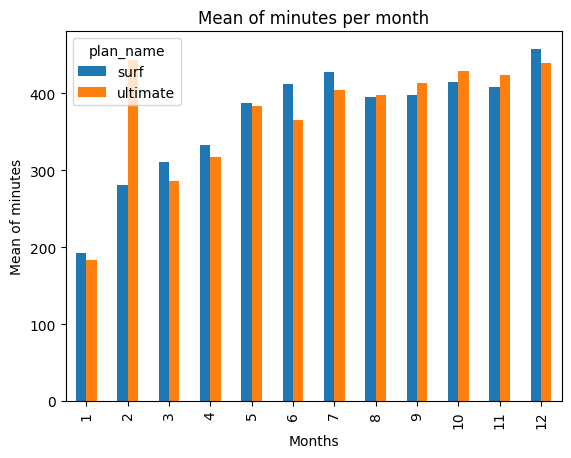

In [34]:
# Compare a duração média das chamadas de cada plano para cada mês distinto. Crie um gráfico de barras para visualizá-lo.

df_merged_call = df_merged.groupby(['month', 'plan_name'])['duration'].mean().unstack().reset_index()

df_merged_call.plot(kind='bar',
                   x='month',
                   y=['surf', 'ultimate'],
                   title='Mean of minutes per month',
                   xlabel='Months',
                   ylabel='Mean of minutes')
plt.show()

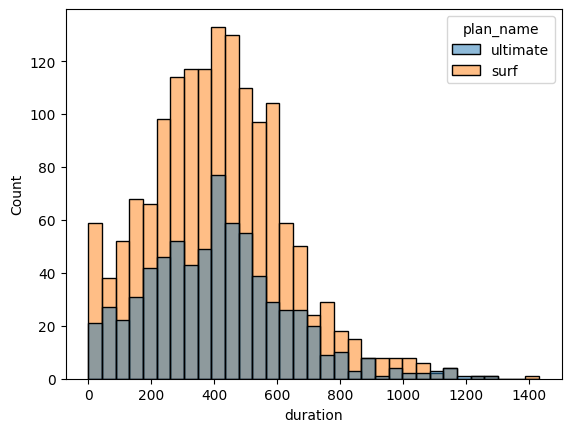

In [35]:
# Compare o número de minutos de que os usuários de cada plano necessitam a cada mês. Construa um histograma.
sns.histplot(data= df_merged, x='duration', hue='plan_name')
plt.show()

In [36]:
# Calcule a média e a variação da duração mensal das chamadas

df_surf = df_merged[df_merged['plan_name'] == 'surf']
df_ultimate = df_merged[df_merged['plan_name'] == 'ultimate']

call_mean_surf = df_surf['duration'].mean()
call_std_surf = np.std(df_surf['duration'])

call_mean_ultimate = df_ultimate['duration'].mean()
call_std_ultimate = np.std(df_ultimate['duration'])

print('Seguem dados estatísticos para plano SURF:')
print('Média:',call_mean_surf)
print('Desvio Padrão:', call_std_surf)
print()
print('Seguem dados estatísticos para plano ULTIMATE:')
print('Média:',call_mean_ultimate)
print('Desvio Padrão:', call_std_ultimate)

Seguem dados estatísticos para plano SURF:
Média: 412.0978899676375
Desvio Padrão: 216.7275541019279

Seguem dados estatísticos para plano ULTIMATE:
Média: 410.18095371669006
Desvio Padrão: 224.5880435470236


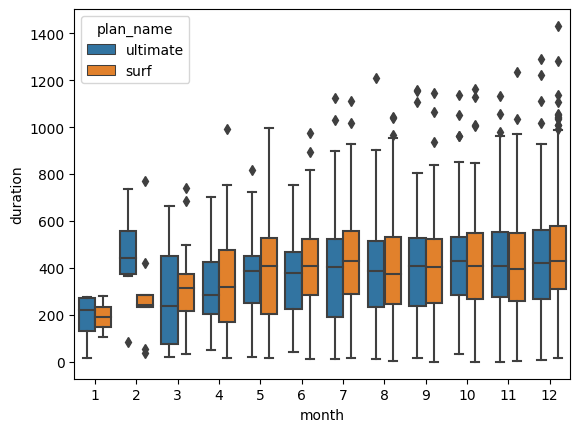

In [37]:
# Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas
sns.boxplot(data=df_merged, x='month', y='duration', hue='plan_name')
plt.show()

De acordo com as informações acima, é possível visualizar que o comportamento entre usuários de ambos os planos é muito similar quando se leva em consideração os dados de minutos de chamadas.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Criação das visualizações solicitadas e interpretação dos dados de chamadas foram realizados propriamente.
</div>


### Mensagens

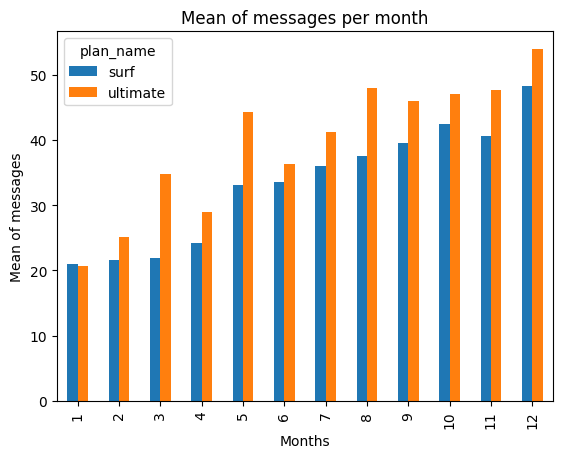

In [38]:
# Compare o número de mensagens que os usuários de cada plano tendem a enviar a cada mês
df_merged_messages = df_merged.groupby(['month', 'plan_name'])['number_of_messages'].mean().unstack().reset_index()

df_merged_messages.plot(kind='bar',
                       x='month',
                       y=['surf', 'ultimate'],
                       title='Mean of messages per month',
                       xlabel='Months',
                       ylabel='Mean of messages')
plt.show()

In [39]:
# Compare a quantidade mensagens enviadas pelos usuários por plano

message_mean_surf = df_surf['number_of_messages'].mean()
message_std_surf = np.std(df_surf['number_of_messages'])

message_mean_ultimate = df_ultimate['number_of_messages'].mean()
message_std_ultimate = np.std(df_ultimate['number_of_messages'])

print('Seguem dados estatísticos de mensagens para plano SURF:')
print('Média:',message_mean_surf)
print('Desvio Padrão:', message_std_surf)
print()
print('Seguem dados estatísticos de mensagens para plano ULTIMATE:')
print('Média:',message_mean_ultimate)
print('Desvio Padrão:', message_std_ultimate)


Seguem dados estatísticos de mensagens para plano SURF:
Média: 40.10965630114566
Desvio Padrão: 33.02197981070137

Seguem dados estatísticos de mensagens para plano ULTIMATE:
Média: 46.29623287671233
Desvio Padrão: 32.91390158148425


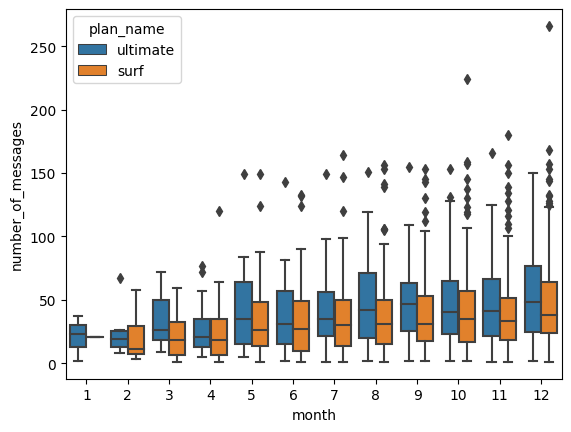

In [40]:
sns.boxplot(data=df_merged, x='month', y='number_of_messages', hue='plan_name')
plt.show()

De acordo com os dados acima, é possível visualizar que o comportamento entre usuários de ambos os planos com relação ao envio de mensagens é muito parecido. A variabilidade dos dados de ambos os planos estão acontecendo praticamente no mesmo intervalo.

### Internet

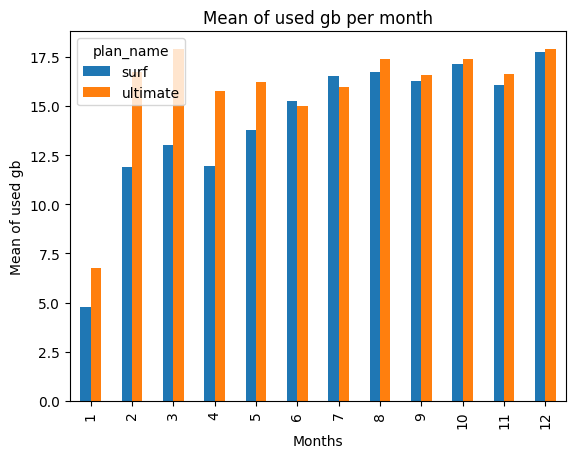

In [41]:
# Compare a quantidade de dados de internet que os usuários de cada plano tendem a consumir a cada mês
df_merged_gb = df_merged.groupby(['month', 'plan_name'])['gb_used'].mean().unstack().reset_index()

df_merged_gb.plot(kind='bar',
                    x='month',
                    y=['surf', 'ultimate'],
                    title='Mean of used gb per month',
                    xlabel='Months',
                    ylabel='Mean of used gb')
plt.show()

In [42]:
# Compare a quantidade de tráfego de internet consumido pelos usuários por plano

gb_mean_surf = df_surf['gb_used'].mean()
gb_std_surf = np.std(df_surf['gb_used'])

gb_mean_ultimate = df_ultimate['gb_used'].mean()
gb_std_ultimate = np.std(df_ultimate['gb_used'])

print('Seguem dados estatísticos de trafego de internet para plano SURF:')
print('Média:',gb_mean_surf)
print('Desvio Padrão:', gb_std_surf)
print()
print('Seguem dados estatísticos de trafego de internet para plano ULTIMATE:')
print('Média:',gb_mean_ultimate)
print('Desvio Padrão:', gb_std_ultimate)

Seguem dados estatísticos de trafego de internet para plano SURF:
Média: 16.325880993511312
Desvio Padrão: 7.697414249080591

Seguem dados estatísticos de trafego de internet para plano ULTIMATE:
Média: 16.834611575321627
Desvio Padrão: 7.6421588454981055


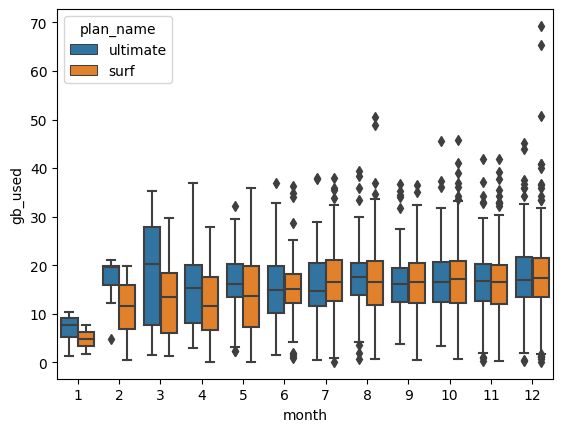

In [43]:
sns.boxplot(data=df_merged, x='month', y='gb_used', hue='plan_name')
plt.show()

De acordo com o diagrama de caixa acima, é possível visualizar que o comportamento entre usuários de ambos os planos é muito similar quando se leva em consideração o tráfego de internet.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Criação das visualizações solicitadas e interpretação dos dados de mensagens e internet foram realizados propriamente.
</div>


## Receita

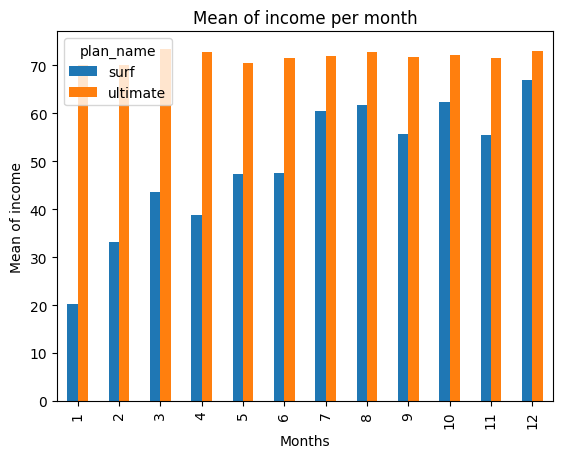

In [44]:
# Compare a quantidade de receita que os usuários de cada plano tendem a gerar a cada mês
df_merged_income = df_merged.groupby(['month', 'plan_name'])['month_income'].mean().unstack().reset_index()

df_merged_income.plot(kind='bar',
                        x='month',
                        y=['surf', 'ultimate'],
                        title='Mean of income per month',
                        xlabel='Months',
                        ylabel='Mean of income')
plt.show()

In [45]:
df_merged_income

plan_name,month,surf,ultimate
0,1,20.240000,70.000000
1,2,33.057289,70.000000
2,3,43.599658,73.392448
3,4,38.823685,72.771377
4,5,47.359365,70.515720
5,6,47.525012,71.476980
6,7,60.513692,71.850414
7,8,61.627799,72.680102
8,9,55.743339,71.812310
9,10,62.387254,72.091689


In [46]:
income_mean_surf = df_merged_income['surf'].mean()
income_std_surf = np.std(df_merged_income['surf'])

income_mean_ultimate = df_merged_income['ultimate'].mean()
income_std_ultimate = np.std(df_merged_income['ultimate'])

print('Seguem dados estatísticos de receita gerada para plano SURF:')
print('Média:',income_mean_surf)
print('Desvio Padrão:', income_std_surf)
print()
print('Seguem dados estatísticos de receita gerada para plano ULTIMATE:')
print('Média:',income_mean_ultimate)
print('Desvio Padrão:', income_std_ultimate)

Seguem dados estatísticos de receita gerada para plano SURF:
Média: 49.4404119482547
Desvio Padrão: 13.215337916128345

Seguem dados estatísticos de receita gerada para plano ULTIMATE:
Média: 71.7698298214507
Desvio Padrão: 1.0861222707404967


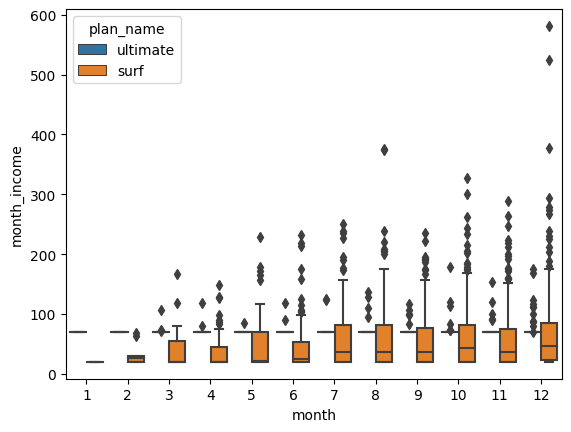

In [47]:
sns.boxplot(data=df_merged, x='month', y='month_income', hue='plan_name')
plt.show()

De acordo com as informações acima, existe uma variabilidade maior de receita para o plano Surf. Isso pode significar que os usuários do plano Surf tendem a extrapolar o consumo previsto no plano com maior frequência, gerando receita extra para a empresa. Já usuários do plano Ultimate apresentam baixa variabilidade de receita, o que pode significar que os mesmos tendem a manter seu consumo dentro do pacote oferecido, gerando baixa receita extra para a empresa.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Tudo certo com as visões e conclusões sobre os dados de receita.
</div>


## Teste hipóteses estatísticas

Vamos utilizar um test t para testar as seguintes hipóteses:

H0: As receitas médias dos usuários dos planos Ultimate e Surf são iguais.

H1: As receitas médias dos usuários dos planos Ultimate e Surf são diferentes.

In [48]:
# Teste as hipóteses

alpha_test_income = .05

result_test_income = st.ttest_ind(df_merged_income['surf'],
                                  df_merged_income['ultimate'],
                                  equal_var=False)

print('value-p:', result_test_income.pvalue)

if result_test_income.pvalue < alpha_test_income:
    print('Rejeitamos a hipótese nula.')
else:
    print('Não podemos rejeitar a hipótese nula.')


value-p: 0.00015601234913092607
Rejeitamos a hipótese nula.



<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Formulação das hipóteses, realização do teste e interpretação do resultado do teste atendem ao esperado.
</div>


Agora vamos tentar entender se há alguma diferença na receita entre usuários da área de NY-NJ em comparação com os usuários das demais áreas.

In [49]:
# Criando dois DataFrames novos para o teste estatóstico

# Dados da região NY-NJ:
df_nynj = df_merged[df_merged['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA']
df_nynj = df_nynj.groupby(['month', 'plan_name'])['month_income'].mean().reset_index()

# Dados das demais regiões:
df_other_regions = df_merged[df_merged['city'] != 'New York-Newark-Jersey City, NY-NJ-PA MSA']
df_other_regions = df_other_regions.groupby(['month', 'plan_name'])['month_income'].mean().reset_index()

Vamos utilizar um test t para testar as seguintes hipóteses:

H0: A receitas média dos usuários da região NY-NJ são iguais às demais regiões.

H1: A receita média dos usuários da região NY-NJ é diferentes das demais regiões.

In [50]:
# Teste as hipóteses

alpha_test_nynj = .05

result_test_nynj = st.ttest_ind(df_nynj['month_income'],
                                df_other_regions['month_income'],
                                equal_var=False)

print('value-p:', result_test_nynj.pvalue)

if result_test_nynj.pvalue < alpha_test_nynj:
    print('Rejeitamos a hipótese nula.')
else:
    print('Não podemos rejeitar a hipótese nula.')

value-p: 0.8463348639539647
Não podemos rejeitar a hipótese nula.



<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Formulação das hipóteses, realização do teste e interpretação do resultado do teste atendem ao esperado.
</div>

## Conclusão geral

Os gráficos de barras e boxplot demonstram que o consumo dos planos Surf e Ultimate ocorre de maneira similar. Ambos apresentam variabilidades dentro do mesmo intervalo de dados a cada mês. No entanto, considerando que o plano Surf oferece menor amplitude de consumo de minutos de ligação, envio de mensagens e uso de dados de internet em comparação ao plano Ultimate, poderíamos considerar que há uma probabilidade de o plano Surf ser mais rentável para a empresa. Isso ocorre porque os clientes do plano Surf frequentemente extrapolariam o pacote contratado e acabariam pagando valores extras por mês.

No entanto, ao analisarmos apenas as médias de receita de cada plano por mês, percebemos que o plano Ultimate apresenta uma média de receita mensal maior e menor variabilidade de dados em comparação ao plano Surf. Entretanto, para verificar se essa diferença é estatisticamente significativa, realizamos um teste-t.

Após a análise dos dados, confirmamos que as médias de receita do plano Ultimate são significativamente maiores do que as médias do plano Surf. Portanto, o plano Ultimate é o mais rentável para a empresa.

Além da comparação entre os planos, também verificamos se há diferença significativa na receita gerada pelos clientes localizados nas cidades de Nova York, Newark e Jersey City em comparação com outras regiões. Embora essa informação pudesse ser relevante para investimentos em divulgação na região, não detectamos diferença significativa nos testes realizados.

Sendo assim, segue resumo da análise:

1. Consumo dos Planos Surf e Ultimate:
    - Os gráficos de barras e boxplot mostram que o consumo dos planos Surf e Ultimate é similar.
    - Ambos apresentam variabilidades dentro do mesmo intervalo de dados a cada mês.


2. Médias de Receita por Plano:
    - Analisando apenas as médias de receita de cada plano por mês:
        - O plano Ultimate apresenta uma média de receita mensal maior.
        - O plano Ultimate também tem menor variabilidade de dados em comparação ao plano Surf.


3. Teste Estatístico:
    - Realizamos um teste-t para verificar a diferença significativa entre as médias de receita dos planos.
    - Confirmamos que as médias de receita do plano Ultimate são significativamente maiores do que as do plano Surf.


4. Clientes nas Cidades de Nova York, Newark e Jersey City:
    - Não detectamos diferença significativa na receita gerada por clientes nessas cidades em comparação com outras regiões.


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Conclusão apresentada com riqueza de detalhes, muito bom!
</div>